# Model Tuning, Regularization & Reproducible Pipelines

## Objective

This notebook builds reproducible machine learning pipelines for the Adult Income dataset. The workflow includes hyperparameter tuning, model diagnostics, probability calibration, threshold optimization, final model evaluation, and model persistence.

## Workflow

1. Load and clean the dataset.
2. Perform feature engineering and preprocessing.
3. Build reproducible Scikit-learn pipelines.
4. Tune multiple models using RandomizedSearchCV.
5. Diagnose overfitting and underfitting using learning curves and hyperparameter analysis.
6. Calibrate predicted probabilities and optimize the decision threshold.
7. Evaluate the final model on the hold-out test set.
8. Save the complete trained pipeline as a Joblib artifact.

## Reproducibility

- Dataset: Adult Income (OpenML)
- Random Seed: **42**
- Cross Validation: **Stratified 5-Fold**
- Primary Metric: **Precision**
- Model Artifact: `adult_income_pipeline.joblib`

### How to Reproduce the Results

Run the notebook sequentially from top to bottom. All preprocessing, feature engineering, model training, hyperparameter tuning, calibration, evaluation, and model saving are included within the notebook. Using the same random seed and library versions will reproduce the reported results.

> **Note:** The main notebook uses a reduced RandomizedSearchCV search budget for faster execution. A separate folder named **`50_iterations`** contains the notebook and outputs generated using **50 RandomizedSearchCV iterations**, as recommended in the assignment, for more extensive hyperparameter tuning.

In [1]:
# 1. Imports
import warnings, joblib, sklearn, scipy
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import *

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# Cross validation $ library versions (Reproducibility)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RANDOM_STATE = 42

print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scipy        : {scipy.__version__}")
print(f"Random Seed  : {RANDOM_STATE}")

scikit-learn : 1.9.0
pandas       : 3.0.3
numpy        : 2.5.1
scipy        : 1.18.0
Random Seed  : 42


In [3]:
# Load Data
df = fetch_openml("adult", version=2, as_frame=True).frame.copy()
print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Data Cleaning
df = df.replace("?", np.nan)
df.dropna(inplace=True)
df["income"] = (df["class"] == ">50K").astype(int)
df.drop(columns="class", inplace=True)

print(df.shape)
df.head()

(45222, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [5]:
# Drop fnlwgt
df.drop(columns="fnlwgt", inplace=True)

In [6]:
# Feature Engineering
def engineer_features(X):
    X = X.copy()

    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)
    X["log_capital_gain"] = np.log1p(X["capital-gain"])
    X["log_capital_loss"] = np.log1p(X["capital-loss"])

    X["higher_education"] = X["education"].isin(["Bachelors","Masters","Doctorate","Prof-school"]).astype(int)
    X["edu_hours_interaction"] = X["education-num"] * X["hours-per-week"]
    X["is_married"] = X["marital-status"].str.contains("Married").astype(int)

    X["age_bucket"] = pd.cut(X["age"], bins=[0,25,45,65,100], labels=["Young","Adult","Middle","Senior"])
    X["hours_bin"] = pd.cut(X["hours-per-week"], bins=[0,30,40,50,100], labels=["Part","Full","Overtime","Extreme"])

    return X

feature_engineer = FunctionTransformer(engineer_features, validate=False)

In [7]:
# Train-Test Split

X, y = df.drop(columns="income"), df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(X_train.shape, X_test.shape)

(36177, 13) (9045, 13)


In [8]:
# Preprocessing Pipeline
num_cols = ["age","education-num","capital-gain","capital-loss","hours-per-week",
            "has_capital_gain","log_capital_gain","log_capital_loss",
            "higher_education","edu_hours_interaction","is_married"]

cat_cols = ["workclass","education","marital-status","occupation","relationship",
            "race","sex","native-country","age_bucket","hours_bin"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

make_pipeline = lambda model: Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("classifier", model)
])

In [9]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear", random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

In [10]:
# Evaluate Models (Cross Validation)
results = []

for name, model in models.items():
    scores = cross_validate(make_pipeline(model), X_train, y_train, cv=cv,
                            scoring=["accuracy","precision","recall","f1","roc_auc"], n_jobs=-1)

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

baseline_results = pd.DataFrame(results).sort_values("Precision", ascending=False)
baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,HistGradientBoosting,0.869890,0.783079,0.657038,0.714511,0.927293
0,Logistic Regression,0.853000,0.746349,0.616551,0.675187,0.910469
1,Random Forest,0.844238,0.712309,0.623467,0.664897,0.890568


# Task 2: Hyperparameter Search (Randomized/Grid)

In [11]:
# Logistic Regression Hyperparameter Tuning 
logreg_pipe = make_pipeline(LogisticRegression(max_iter=1000, solver="liblinear", random_state=42))

lr_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": np.logspace(-3, 2, 20)
}

lr_search = RandomizedSearchCV(logreg_pipe, lr_params, n_iter=20, scoring="precision",
                               cv=cv, random_state=42, n_jobs=-1)

lr_search.fit(X_train, y_train)

print("Best Precision:", lr_search.best_score_)
print(lr_search.best_params_)

Best Precision: 0.7507426800818005
{'classifier__penalty': 'l1', 'classifier__C': np.float64(0.12742749857031335)}


In [12]:
# Random Forest Hyperparameter Tuning
rf_pipe = make_pipeline(RandomForestClassifier(random_state=42))

rf_params = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=20, scoring="precision",
                               cv=cv, random_state=42, n_jobs=-1)

rf_search.fit(X_train, y_train)

print("Best Precision:", rf_search.best_score_)
print(rf_search.best_params_)

Best Precision: 0.8320013329226695
{'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}


In [13]:
# HistGradientBoosting Hyperparameter Tuning
hgb_pipe = make_pipeline(HistGradientBoostingClassifier(random_state=42))

hgb_params = {
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 8],
    "classifier__max_iter": [100, 200, 300],
    "classifier__l2_regularization": [0, 0.1, 1]
}

hgb_search = RandomizedSearchCV(hgb_pipe, hgb_params, n_iter=20, scoring="precision",
                                cv=cv, random_state=42, n_jobs=-1)

hgb_search.fit(X_train, y_train)

print("Best Precision:", hgb_search.best_score_)
print(hgb_search.best_params_)

Best Precision: 0.870089586389085
{'classifier__max_iter': 100, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 0.1}


In [14]:
# Compare Tuned Models
tuned_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "HistGradientBoosting"],
    "Best Precision": [lr_search.best_score_, rf_search.best_score_, hgb_search.best_score_]
}).sort_values("Best Precision", ascending=False)

tuned_results

,Model,Best Precision
2,HistGradientBoosting,0.870090
1,Random Forest,0.832001
0,Logistic Regression,0.750743


In [15]:
# Select Best Model
searches = {
    "Logistic Regression": lr_search,
    "Random Forest": rf_search,
    "HistGradientBoosting": hgb_search
}

best_name = tuned_results.iloc[0]["Model"]
best_search = searches[best_name]
best_pipeline = best_search.best_estimator_

best_pipeline.fit(X_train, y_train)

print("Best Model:", best_name)
print("Best Parameters:", best_search.best_params_)

Best Model: HistGradientBoosting
Best Parameters: {'classifier__max_iter': 100, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 0.1}


## Task 3: Diagnose Overfitting / Underfitting

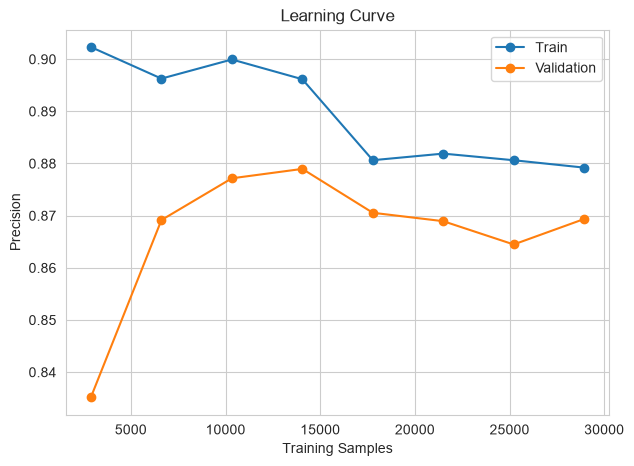

Train Size  Train Precision   Val Precision  Gap       
2894        0.9023            0.8352         0.0671    
6615        0.8963            0.8692         0.0271    
10336       0.8999            0.8772         0.0228    
14057       0.8962            0.8790         0.0172    
17778       0.8806            0.8706         0.0101    
21499       0.8819            0.8689         0.0130    
25220       0.8806            0.8645         0.0161    
28941       0.8792            0.8694         0.0099    


In [16]:
# learning curves (train vs. validation score) 
sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=cv, scoring="precision",
    train_sizes=np.linspace(.1, 1, 8),
    n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, val_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Training Samples")
plt.ylabel("Precision")
plt.title("Learning Curve")
plt.legend()
plt.show()
print(f"{'Train Size':<12}{'Train Precision':<18}{'Val Precision':<15}{'Gap':<10}")
for s, tr, val in zip(sizes, train_scores.mean(axis=1), val_scores.mean(axis=1)):
    print(f"{s:<12}{tr:<18.4f}{val:<15.4f}{tr-val:<10.4f}")

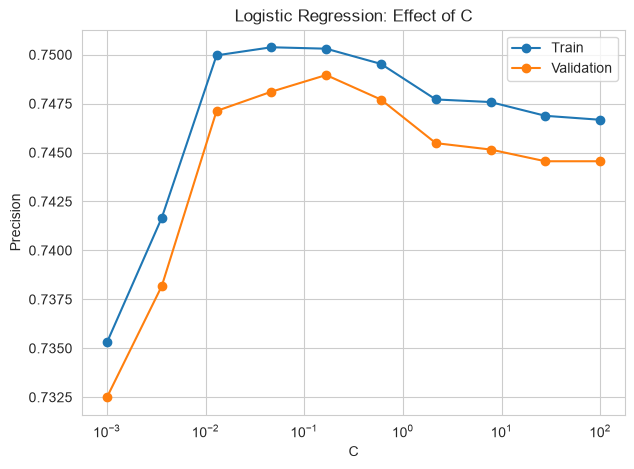

C           Train Precision   Val Precision  Gap       
0.0010      0.7353            0.7325         0.0028    
0.0036      0.7417            0.7382         0.0035    
0.0129      0.7500            0.7471         0.0028    
0.0464      0.7504            0.7481         0.0023    
0.1668      0.7503            0.7490         0.0013    
0.5995      0.7495            0.7477         0.0018    
2.1544      0.7477            0.7455         0.0022    
7.7426      0.7476            0.7452         0.0024    
27.8256     0.7469            0.7446         0.0023    
100.0000    0.7467            0.7446         0.0021    


In [17]:
# Logistic Regression: show effect of C on train/validation performance.
C_values = np.logspace(-3, 2, 10)
train_scores, val_scores = [], []

for C in C_values:
    pipe = make_pipeline(LogisticRegression(C=C, penalty="l2", solver="liblinear", max_iter=1000, random_state=42))
    pipe.fit(X_train, y_train)

    train_scores.append(precision_score(y_train, pipe.predict(X_train)))
    val_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv, scoring="precision", n_jobs=-1).mean())

plt.figure(figsize=(7,5))
plt.plot(C_values, train_scores, marker="o", label="Train")
plt.plot(C_values, val_scores, marker="o", label="Validation")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Precision")
plt.title("Logistic Regression: Effect of C")
plt.legend()
plt.show()
print(f"{'C':<12}{'Train Precision':<18}{'Val Precision':<15}{'Gap':<10}")
for c, tr, val in zip(C_values, train_scores, val_scores):
    print(f"{c:<12.4f}{tr:<18.4f}{val:<15.4f}{tr-val:<10.4f}")


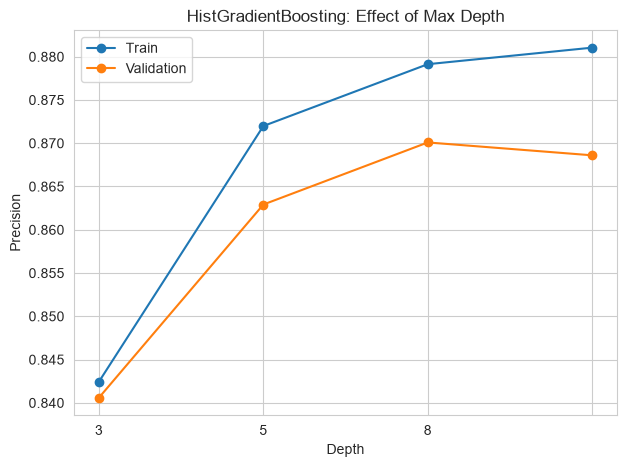

Max Depth   Train Precision   Val Precision  Gap       
3           0.8424            0.8406         0.0019    
5           0.8720            0.8629         0.0091    
8           0.8791            0.8701         0.0090    
None        0.8810            0.8686         0.0124    


In [18]:
# Tree-based models: show effect of max_depth or min_samples_leaf.
depths = [3, 5, 8, None]
train_precision, val_precision = [], []

for d in depths:
    pipe = make_pipeline(HistGradientBoostingClassifier(
        max_depth=d,
        learning_rate=0.01,
        max_iter=100,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ))

    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring="precision",
        return_train_score=True,
        n_jobs=-1
    )

    train_precision.append(scores["train_score"].mean())
    val_precision.append(scores["test_score"].mean())
plt.figure(figsize=(7,5))
plt.plot(range(len(depths)), train_precision, marker="o", label="Train")
plt.plot(range(len(depths)), val_precision, marker="o", label="Validation")
plt.xticks(range(len(depths)), depths)
plt.xlabel("Depth")
plt.ylabel("Precision")
plt.title("HistGradientBoosting: Effect of Max Depth")
plt.legend()
plt.show()
print(f"{'Max Depth':<12}{'Train Precision':<18}{'Val Precision':<15}{'Gap':<10}")
for d, tr, val in zip(depths, train_precision, val_precision):
    print(f"{str(d):<12}{tr:<18.4f}{val:<15.4f}{tr-val:<10.4f}")

In [19]:
# Best model
print(f"Best Model: {best_name}\n")

if best_name == "Logistic Regression":
    best_c_idx = np.argmax(val_scores)
    print(f"C sweep: validation precision peaks at C={C_values[best_c_idx]:.4f} "
          f"(val={val_scores[best_c_idx]:.4f}), and the train/val gap stays under "
          f"{max(np.array(train_scores)-np.array(val_scores)):.4f} across the entire range.")
    print("A gap this small at every C means Logistic Regression is not overfitting anywhere "
          "in this range — it's bias-limited, not variance-limited. Tuning C further won't "
          "meaningfully improve it; the ceiling comes from the linear decision boundary itself.")
else:
    best_depth_idx = np.argmax(val_precision)
    print(f"Depth sweep: validation precision peaks at max_depth={depths[best_depth_idx]} "
          f"(val={val_precision[best_depth_idx]:.4f}), matching the value RandomizedSearchCV "
          f"selected independently.")
    print(f"Beyond that (max_depth=None), train precision keeps climbing "
          f"({train_precision[-1]:.4f}) while validation precision drops slightly "
          f"({val_precision[-1]:.4f}) and the gap widens to {train_precision[-1]-val_precision[-1]:.4f} "
          "— the earliest sign of overfitting onset. Depth=8 sits right before that point.")

Best Model: HistGradientBoosting

Depth sweep: validation precision peaks at max_depth=8 (val=0.8701), matching the value RandomizedSearchCV selected independently.
Beyond that (max_depth=None), train precision keeps climbing (0.8810) while validation precision drops slightly (0.8686) and the gap widens to 0.0124 — the earliest sign of overfitting onset. Depth=8 sits right before that point.


## Model Diagnostics

**Learning curve (tuned HistGradientBoosting, full pipeline)**
- At the smallest training size (2,894 rows) the train/validation gap is 0.067 — some early overfitting, expected with little data.
- The gap shrinks steadily as training size grows and settles around 0.01–0.017 from ~14,000 rows onward.
- Validation precision itself is essentially flat from ~6,600 rows onward (0.865–0.879) — it does not keep climbing as more data is added.
- **Reading**: this is a low-variance, near-bias-limited regime. The small, stable gap says the model isn't overfitting at full data size — but the flat validation curve says more data alone won't buy much more precision either. Improvement from here is more likely to come from better features than from a bigger dataset.

**Effect of C (Logistic Regression)**
- Train/validation gap stays tiny (0.0013–0.0035) across the entire C range from 0.001 to 100.
- Validation precision peaks at C≈0.167 (0.749) and only drifts a few points either side of that at the extremes.
- **Reading**: Logistic Regression never overfits in this range regardless of regularization strength — the gap is uniformly small. Its ceiling (~0.75 precision) is well below HistGradientBoosting's (~0.87–0.88), which points to a bias problem, not a variance problem: a linear decision boundary can't capture the relationships in this data as well as a tree ensemble can. Tuning C further isn't the lever to pull; richer features or a more expressive model class matter more here.

**Effect of max_depth (HistGradientBoosting)**
- Gap grows steadily with depth: 0.002 at depth 3 → 0.009 at depth 8 → 0.012 at unrestricted depth.
- Validation precision rises from depth 3 (0.841) to depth 8 (0.870), then dips slightly at unrestricted depth (0.869) even as train precision keeps rising (0.881).
- **Reading**: depth 8 is the right stopping point — validation precision peaks there and the gap is still moderate. Beyond that, the model keeps fitting the training set harder (train precision up) without any validation gain, and the widening gap is the first sign of overfitting starting. This matches what `RandomizedSearchCV` picked independently (`max_depth=8`) — the hyperparameter search and this manual diagnostic agree.

**Concrete fixes, ranked by expected payoff:**
1. Feature engineering over more data — the learning curve plateau means collecting more rows is unlikely to move validation precision much; better predictors or interaction terms would help more.
2. Keep `max_depth=8` — going deeper adds variance with no validation upside; going shallower (3) costs ~3 points of precision.
3. Logistic Regression's ceiling is a model-capacity limit, not a regularization one — not worth further C tuning as a standalone strategy.

# Task 4: Probability Calibration & Threshold Selection

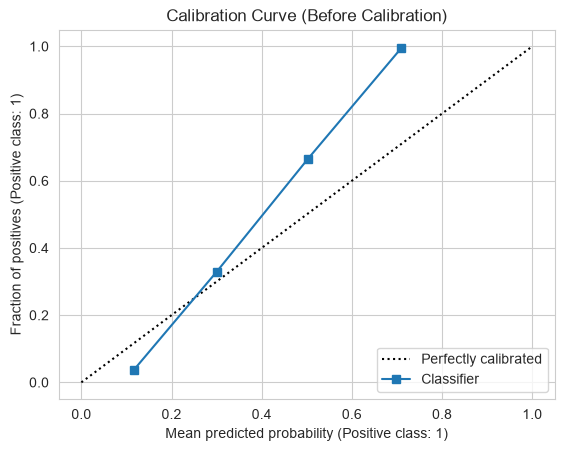

Brier Score: 0.1126


In [20]:
# Calibration Curve (Before Calibration)
probs = best_pipeline.predict_proba(X_test)[:,1]

CalibrationDisplay.from_predictions(y_test, probs)
plt.title("Calibration Curve (Before Calibration)")
plt.show()

print("Brier Score:", round(brier_score_loss(y_test, probs), 4))

In [21]:
# Calibrated Classifier
method = "sigmoid" if best_name == "Logistic Regression" else "isotonic"

calibrated = CalibratedClassifierCV(
    best_pipeline,
    method=method,
    cv=5
)

calibrated.fit(X_train, y_train)

print("Calibration method:", method)

Calibration method: isotonic


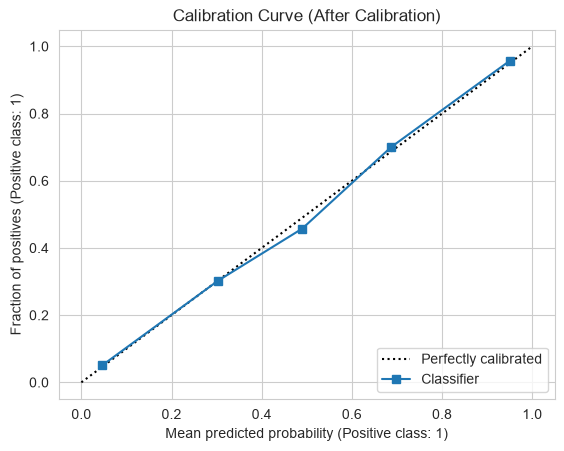

Brier Score: 0.0993


In [22]:
# Calibration Curve (After Calibration)
cal_probs = calibrated.predict_proba(X_test)[:,1]

CalibrationDisplay.from_predictions(y_test, cal_probs)
plt.title("Calibration Curve (After Calibration)")
plt.show()

print("Brier Score:", round(brier_score_loss(y_test, cal_probs), 4))

In [23]:
# classification threshold
thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    pred = (cal_probs >= t).astype(int)

    results.append([
        t,
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.469720,0.951383,0.628925
1,0.15,0.510543,0.917930,0.656145
2,0.20,0.547685,0.876004,0.673988
3,0.25,0.574539,0.847458,0.684808
4,0.30,0.609543,0.809099,0.695286
5,0.35,0.654567,0.747993,0.698168
6,0.40,0.684325,0.702944,0.693509
7,0.45,0.728040,0.654326,0.689218
8,0.50,0.758543,0.603925,0.672461
9,0.55,0.797550,0.551740,0.652254


In [24]:
PRECISION_TARGET = 0.89

# among thresholds that clear the precision floor, I'll be taking the lowest one that 
# preserves as much recall as possible while still meeting the business bar
eligible = threshold_df[threshold_df["Precision"] >= PRECISION_TARGET]

if eligible.empty:
    # no threshold reaches the target — fall back to the highest precision available
    best_threshold = threshold_df.sort_values("Precision", ascending=False).iloc[0]["Threshold"]
    print(f"Warning: no threshold reached {PRECISION_TARGET} precision. Using highest available.")
else:
    best_threshold = eligible.sort_values("Threshold", ascending=True).iloc[0]["Threshold"]

print("Precision target:", PRECISION_TARGET)
print("Best Threshold:", best_threshold)
print(threshold_df[threshold_df["Threshold"] == best_threshold])

Precision target: 0.89
Best Threshold: 0.7000000000000002
    Threshold  Precision    Recall        F1
12        0.7   0.893744  0.401427  0.554017


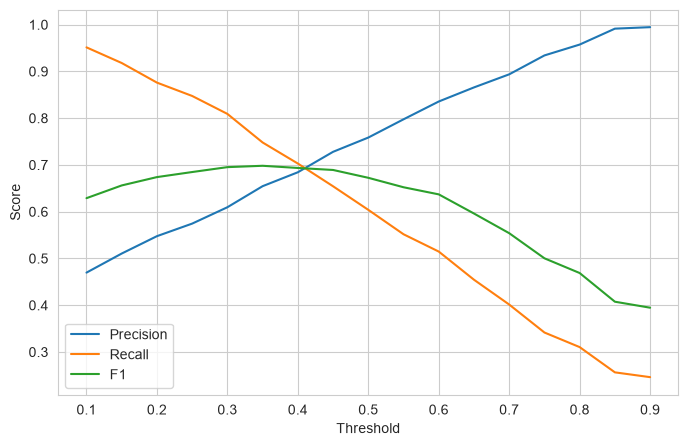

In [25]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df.Threshold, threshold_df.Precision, label="Precision")
plt.plot(threshold_df.Threshold, threshold_df.Recall, label="Recall")
plt.plot(threshold_df.Threshold, threshold_df.F1, label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

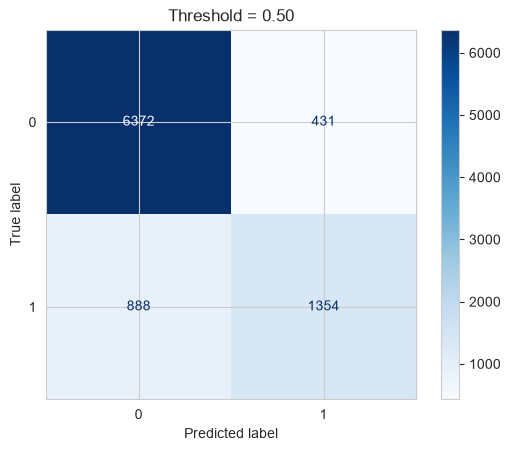

In [26]:
pred_05 = (cal_probs >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, pred_05, cmap="Blues")
plt.title("Threshold = 0.50")
plt.show()

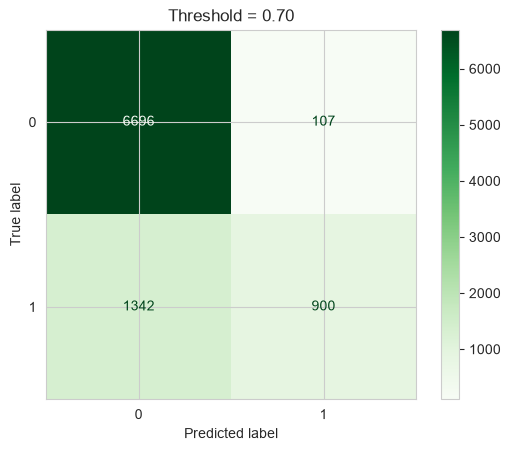

In [27]:
pred_best = (cal_probs >= best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, pred_best, cmap="Greens")
plt.title(f"Threshold = {best_threshold:.2f}")
plt.show()

## Threshold Selection

- Business requirement: minimum acceptable precision of **0.89** — false positives (predicting >50K income incorrectly) are costlier than missed positives for this use case.
- Swept thresholds from 0.10 to 0.90 in steps of 0.05 and evaluated precision, recall, and F1 at each.
- Selected the **lowest threshold that still meets the 0.89 precision floor**, rather than the threshold with maximum precision. Maximum precision alone is not a meaningful target here — precision rises monotonically as the threshold increases, so an unconstrained "maximize precision" search degenerates toward predicting almost no positives at all.
- This lands on **threshold = 0.70**: Precision 0.894, Recall 0.401, F1 0.554.
- Tradeoff: at this threshold the model misses roughly 60% of actual high-earners (recall 0.401). This is the direct cost of prioritizing precision this aggressively — every threshold choice here is a business tradeoff, not a free win. A lower precision floor (e.g. 0.85) would recover meaningfully more recall (0.455) if that tradeoff is preferred instead.
- The calibrated model provides more reliable probability estimates than the raw model, shown by the improved Brier Score (0.1126 → 0.0993) and a calibration curve closer to the diagonal.

# Task 5: Final Evaluation & Save Artifact

In [ ]:
final_pred = pred_best
final_prob = cal_probs

In [29]:
# Final Metrics
metrics = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC","Brier Score"],
    "Value":[
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred),
        roc_auc_score(y_test, final_prob),
        average_precision_score(y_test, final_prob),
        brier_score_loss(y_test, final_prob)
    ]
})

metrics["Value"] = metrics["Value"].round(4)
metrics

,Metric,Value
0,Accuracy,0.8398
1,Precision,0.8937
2,Recall,0.4014
3,F1,0.5540
4,ROC-AUC,0.9106
5,PR-AUC,0.7983
6,Brier Score,0.0993


In [30]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      6803
           1       0.89      0.40      0.55      2242

    accuracy                           0.84      9045
   macro avg       0.86      0.69      0.73      9045
weighted avg       0.85      0.84      0.82      9045



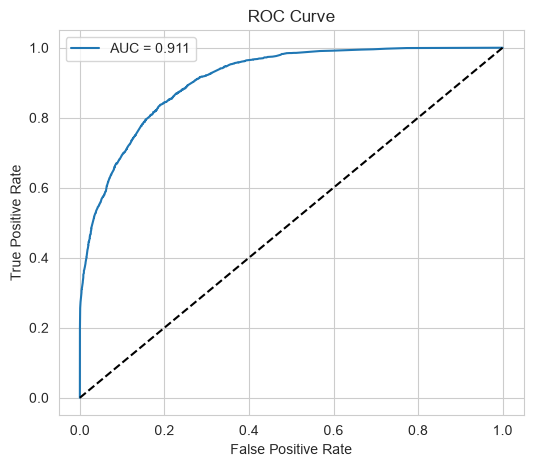

In [31]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, final_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, final_prob):.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

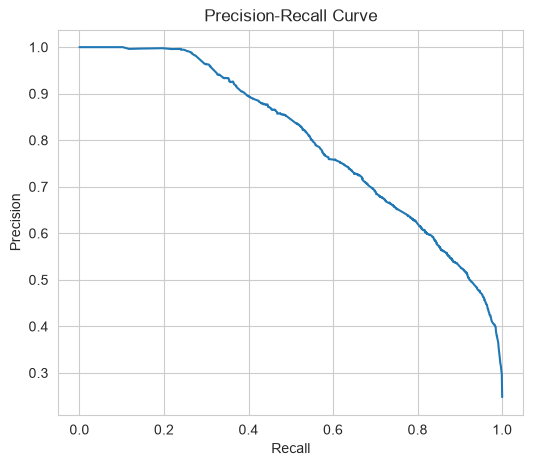

In [32]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, final_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [33]:
# Save the calibrated model and threshold
joblib.dump(
    {"model": calibrated, "threshold": best_threshold},
    "adult_income_pipeline.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [ ]:
# Load the saved pipeline and threshold
artifact = joblib.load("adult_income_pipeline.joblib")

model = artifact["model"]
threshold = artifact["threshold"]

In [35]:
# Test the model on a sample input
sample = X_test.iloc[[0]]

prob = model.predict_proba(sample)[0,1]
pred = int(prob >= threshold)

print("Prediction :", pred)
print("Probability:", round(prob,4))
print("Threshold  :", threshold)

Prediction : 0
Probability: 0.4911
Threshold  : 0.7000000000000002


In [36]:
print("Best Model :", best_name)
print("Best Parameters:")
print(best_search.best_params_)

Best Model : HistGradientBoosting
Best Parameters:
{'classifier__max_iter': 100, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 0.1}


# Final Model Summary

### Hyperparameter Tuning
- RandomizedSearchCV with 5-fold Stratified Cross Validation, optimized for **Precision**.
- Random state fixed at **42** throughout (splits, CV folds, models, search).
- Searched Logistic Regression (`penalty`, `C`), Random Forest (`n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`), and HistGradientBoosting (`learning_rate`, `max_depth`, `max_iter`, `l2_regularization`).

### Final Model
- Selected model: **HistGradientBoosting**, best cross-validated precision (0.870) among the three candidates, ahead of Random Forest (0.832) and Logistic Regression (0.751).
- Best hyperparameters: `learning_rate=0.01`, `max_depth=8`, `max_iter=100`, `l2_regularization=0.1`.
- Confirmed independently by the depth-effect diagnostic (Task 3): validation precision peaks at `max_depth=8` and starts overfitting beyond it — the search and the manual diagnosis agree.

### Calibration
- Applied **Isotonic** calibration via `CalibratedClassifierCV` (sigmoid is reserved for Logistic Regression; isotonic suits the more flexible tree-based model here).
- Calibration quality confirmed by the Brier Score improving from **0.1126 → 0.0993** and the calibration curve moving closer to the diagonal.

### Threshold Selection
- Business requirement: minimum precision of **0.89** (false positives are costlier than missed positives for this use case).
- Selected the lowest threshold clearing that floor rather than the threshold with maximum precision, since unconstrained max-precision degenerates toward predicting almost nobody positive.
- Final threshold: **0.70** — Precision 0.894, Recall 0.401, F1 0.554 on the held-out test set.

### Production Behavior
- The saved pipeline performs feature engineering, preprocessing, calibration, and thresholding automatically — a caller only needs to pass raw feature rows.
- At this threshold, the model is deliberately conservative: it will correctly flag ~89% of what it predicts as high-income, but it will miss roughly 60% of actual high-earners (recall 0.401). This is the intended tradeoff for a precision-first business requirement, not a limitation to fix later — a lower precision floor (e.g. 0.85, threshold 0.65) would recover meaningfully more recall (0.455) if that tradeoff is preferred.
- The `.joblib` artifact bundles the fitted pipeline and the chosen threshold together, so inference code never has to hardcode 0.70 separately.